In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt


In [5]:
import torch
import sys

sys.path.append("/content/drive/MyDrive/project_Landset08/training")

from model import ThermalFusionNet
from dataset import ThermalDataset


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ThermalFusionNet(
    feat_channels=64,
    n_refine=6,
    up_scale=1
).to(device)


Load trained checkpoint

In [9]:
ckpt_path = "/content/drive/MyDrive/project_Landset08/training/checkpoints/epoch_050.pt"

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


KeyError: 'model_state_dict'

In [10]:
type(checkpoint)


collections.OrderedDict

In [11]:
ckpt_path = "/content/drive/MyDrive/project_Landset08/training/checkpoints/epoch_050.pt"

state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded successfully")


RuntimeError: Error(s) in loading state_dict for ThermalFusionNet:
	Missing key(s) in state_dict: "refine.4.conv1.weight", "refine.4.conv1.bias", "refine.4.conv2.weight", "refine.4.conv2.bias", "refine.5.conv1.weight", "refine.5.conv1.bias", "refine.5.conv2.weight", "refine.5.conv2.bias". 

In [12]:
model = ThermalFusionNet(
    feat_channels=64,
    n_refine=4,   # 🔑 MUST match training
    up_scale=1
).to(device)


In [13]:
ckpt_path = "/content/drive/MyDrive/project_Landset08/training/checkpoints/epoch_050.pt"

state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded perfectly")


✅ Model loaded perfectly


create folders

In [14]:
import os

base_dir = "/content/drive/MyDrive/project_Landset08"
infer_dir = base_dir + "/inference_results"

os.makedirs(infer_dir + "/SR_Thermal", exist_ok=True)
os.makedirs(infer_dir + "/visuals", exist_ok=True)

print("✅ Inference folders ready")


✅ Inference folders ready


Load model + dataset (INFERENCE MODE)

In [15]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/content/drive/MyDrive/project_Landset08/training")

from model import ThermalFusionNet
from dataset import ThermalDataset


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ThermalFusionNet(
    feat_channels=64,
    n_refine=4,
    up_scale=1
).to(device)

ckpt_path = "/content/drive/MyDrive/project_Landset08/training/checkpoints/epoch_050.pt"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded for inference")


Using device: cpu
✅ Model loaded for inference


STEP 3: Load dataset (no DataLoader yet)

In [17]:
base_dir = "/content/drive/MyDrive/project_Landset08/final_dataset"
split_file = base_dir + "/splits/train.txt"

dataset = ThermalDataset(base_dir, split_file)

print("✅ Samples available:", len(dataset))


✅ Samples available: 462


STEP 4: Run inference on ONE sample (safe test ✅)

In [18]:
idx = 0  # change later
lr, rgb, hr = dataset[idx]

lr = lr.unsqueeze(0).to(device)
rgb = rgb.unsqueeze(0).to(device)

with torch.no_grad():
    sr = model(lr, rgb)

print("LR:", lr.shape)
print("SR:", sr.shape)


LR: torch.Size([1, 1, 264, 264])
SR: torch.Size([1, 1, 264, 264])


STEP 5: Save the SR thermal image

In [19]:
sr_np = sr.squeeze().cpu().numpy()
sr_np = np.clip(sr_np * 255.0, 0, 255).astype(np.uint8)

img_id = dataset.ids[idx]
save_path = f"/content/drive/MyDrive/project_Landset08/inference_results/SR_Thermal/{img_id}_SR.npy"

np.save(save_path, sr_np)

print("✅ Saved SR thermal:", save_path)


✅ Saved SR thermal: /content/drive/MyDrive/project_Landset08/inference_results/SR_Thermal/0000569_SR.npy


STEP 6: Visual comparison (VERY IMPORTANT FOR REPORT)

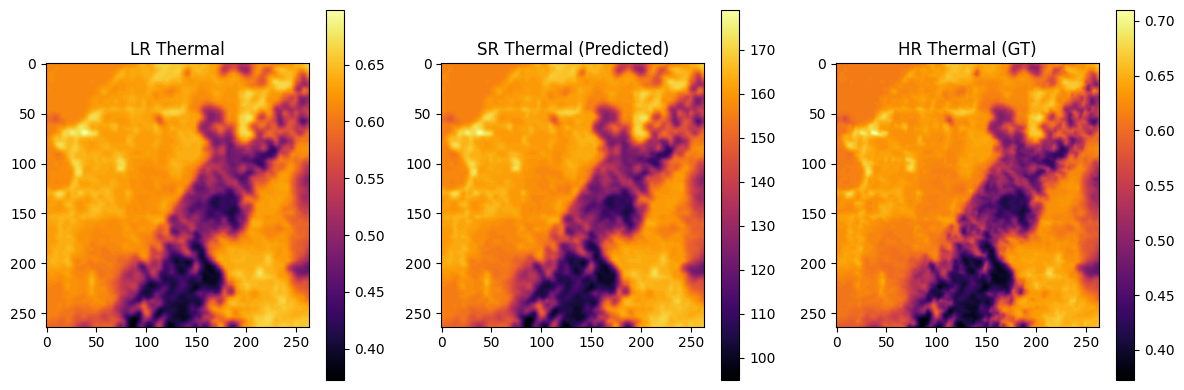

In [20]:
lr_np = lr.squeeze().cpu().numpy()
hr_np = hr.squeeze().cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("LR Thermal")
plt.imshow(lr_np, cmap="inferno")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("SR Thermal (Predicted)")
plt.imshow(sr_np, cmap="inferno")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("HR Thermal (GT)")
plt.imshow(hr_np, cmap="inferno")
plt.colorbar()

plt.tight_layout()
plt.show()


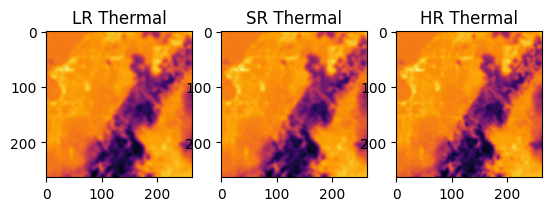

In [21]:
vmin = hr_np.min()
vmax = hr_np.max()

plt.subplot(1,3,1)
plt.title("LR Thermal")
plt.imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)

plt.subplot(1,3,2)
plt.title("SR Thermal")
plt.imshow(sr_np/255.0, cmap="inferno", vmin=vmin, vmax=vmax)

plt.subplot(1,3,3)
plt.title("HR Thermal")
plt.imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)

plt.show()
